# Z-score removal of outliers

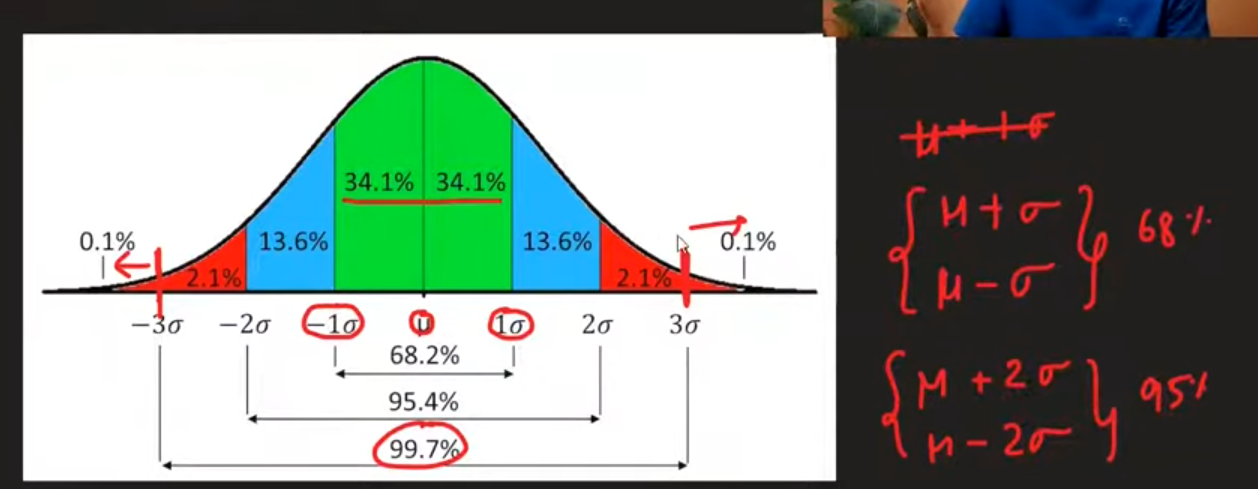

values outside of [mean - 3std_dev, mean + 3std_dev] considered outliers

##### **For finding outliers in normally distributed data**

## Detection and handling of outliers
Steps : 
1. Z-score transformation of the variable
2. Detemine outliers outside the range [-3,3]
3. Deal with outliers :
    -trimming or 
    - capping

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [16]:
df = pd.read_csv('../datasets/placement.csv')

df

,Unnamed: 0,cgpa,iq,placement
0,0,6.8,123.0,1
1,1,5.9,106.0,0
2,2,5.3,121.0,0
3,3,7.4,132.0,1
4,4,5.8,142.0,0
...,...,...,...,...
95,95,4.3,200.0,0
96,96,4.4,42.0,0
97,97,6.7,182.0,1
98,98,6.3,103.0,1


In [4]:
df = df.drop(columns=['Unnamed: 0'])
df.head()

,cgpa,iq,placement
0,6.8,123.0,1
1,5.9,106.0,0
2,5.3,121.0,0
3,7.4,132.0,1
4,5.8,142.0,0


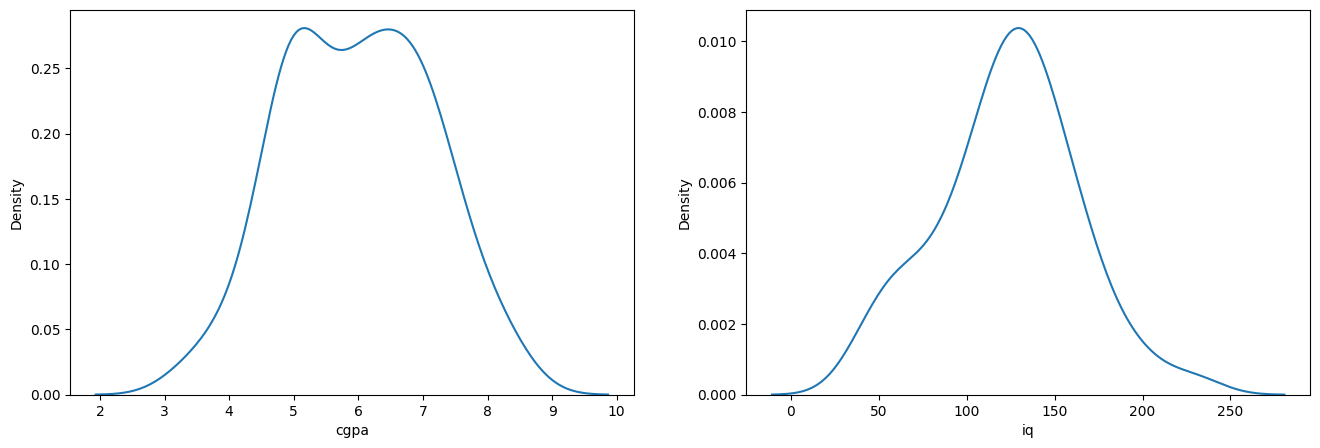

In [5]:
# Check distribution of input cols (cgpa and iq)
plt.figure(figsize=(16,5))
plt.subplot(1,2,1)
sns.kdeplot(df['cgpa'])

plt.subplot(1,2,2)
sns.kdeplot(df['iq'])

plt.show()

In [6]:
# iq seems to be normally distributed 
## Checking its metrics
df['iq'].describe()

count    100.000000
mean     123.580000
std       39.944198
min       37.000000
25%      101.500000
50%      127.500000
75%      149.000000
max      233.000000
Name: iq, dtype: float64

In [12]:
# Find boundary values 
upper_limit = df['iq'].mean() + 3*df['iq'].std()
lower_limit = df['iq'].mean() - 3*df['iq'].std()
lower_limit

np.float64(3.747404646770221)

In [9]:
# Find outliers
outliers = df[(df['iq'] > upper_limit) | (df['iq'] < lower_limit)]
outliers

,cgpa,iq,placement


No outliers hahahahaha

*~~Shit~~*

Let's try on cgpa then T_T

In [13]:
# Find boundary values 
upper_limit = df['cgpa'].mean() + 3*df['cgpa'].std()
lower_limit = df['cgpa'].mean() - 3*df['cgpa'].std()
upper_limit

np.float64(9.421901021332708)

In [18]:
# Find outliers
outliers = df[(df['cgpa'] > upper_limit) | (df['cgpa'] < lower_limit)]
outliers

,Unnamed: 0,cgpa,iq,placement


NO outliers T_T

### Anyway this is just demo, moving on

Demonstrating trimming and capping

In [ ]:
# Trimming
new_df = df[(df['cgpa'] < upper_limit) & (df['cgpa'] > lower_limit)]
new_df
# no records removed cuz no outliers

,Unnamed: 0,cgpa,iq,placement
0,0,6.8,123.0,1
1,1,5.9,106.0,0
2,2,5.3,121.0,0
3,3,7.4,132.0,1
4,4,5.8,142.0,0
...,...,...,...,...
95,95,4.3,200.0,0
96,96,4.4,42.0,0
97,97,6.7,182.0,1
98,98,6.3,103.0,1


In [21]:
# Capping
new_df_cap = pd.DataFrame(np.where(
    df['cgpa'] > upper_limit, # condition -> if cgpa > upper limit
    upper_limit, #if true -> replace with upper_limit
    np.where( #else
        df['cgpa'] < lower_limit, # again condition -. if cgpa < lower limit
        lower_limit, # if true -> replace with lower_limit
        df['cgpa'] # else let it be as is
    ) 
))

new_df_cap

,0
0,6.8
1,5.9
2,5.3
3,7.4
4,5.8
...,...
95,4.3
96,4.4
97,6.7
98,6.3


### Approach 2 - using z-score transformation

In [22]:
df['cgpa_zscore'] = (df['cgpa'] - df['cgpa'].mean())/ df['cgpa'].std()
df.head()

,Unnamed: 0,cgpa,iq,placement,cgpa_zscore
0,0,6.8,123.0,1,0.707394
1,1,5.9,106.0,0,-0.079571
2,2,5.3,121.0,0,-0.604214
3,3,7.4,132.0,1,1.232038
4,4,5.8,142.0,0,-0.167012


In [24]:
# finding outliers
outliers = df[(df['cgpa_zscore'] > 3) | (df['cgpa_zscore'] < -3)]
outliers 

,Unnamed: 0,cgpa,iq,placement,cgpa_zscore


Then same trimming or capping as you wish